<a href="https://colab.research.google.com/github/muthutaj2323a/Final-Year-Project-Muthu/blob/main/Muthu_model_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automated Detection of Potato Leaf Diseases Using Deep Convolutional Neural Networks**

# **Download and Nested Extraction**
This block downloads the main zip and then extracts the inner Potato Image.zip file identified in your screenshot.

In [ ]:
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from PIL import Image

# Download the dataset ---
!wget https://data.mendeley.com/public-api/zip/ttgtfp3vjb/download/1 -O dataset.zip

#  Extract main zip ---
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('main_folder')

#  Extract the inner image zip ---
# Based on your file path: main_folder/Potato disease classification/Potato Image.zip
inner_zip_path = 'main_folder/Potato disease classification/Potato Image.zip'
data_dir = 'extracted_images'

with zipfile.ZipFile(inner_zip_path, 'r') as zip_ref:
    zip_ref.extractall(data_dir)

print("Data extracted to:", data_dir)

--2026-02-11 03:25:34--  https://data.mendeley.com/public-api/zip/ttgtfp3vjb/download/1
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/ttgtfp3vjb-1.zip?X-Amz-Security-Token=IQoJb3JpZ2luX2VjEOv%2F%2F%2F%2F%2F%2F%2F%2F%2F%2FwEaCWV1LXdlc3QtMSJGMEQCIHOi7B0OBA6G8KDl2vHo%2FkGpNH3Z3I5MvCOHPblDw3N2AiAWdQ4fbp3ZI2%2F3Mls3TkqCzL4acVOb%2FtAf3xEHEZqxDiqVBQi0%2F%2F%2F%2F%2F%2F%2F%2F%2F%2F8BEAQaDDM2NzE0NzM4MzgyNSIM7Z1uzu8rXS9EBcbJKukE7U86EnSa4dBkWpCWS%2FEBKiPViumjMdUHzZ6JZdF74Gsu8lRr2jp3J%2BLBKIa3zc97On7k5IyBYu1irx3B2Omq0%2BsOdatlNj3hOyvx3yjyPcqcXBXac3MRIhymo9n07Fpzv3GKw4xdB5rDNPV%2FY4dG5HD835aWV50asXg9ZdRFk4Xj5IXpsROGJp3ULWB%2Fhz18LXw57pyLsa1VAI5Cncg5QuAAeP3m3ru%2FjjozbSUaoqQNWvcmBnU86%2BHdv2%2BQ1pxYI3TJdyvGOfkCX8tnWwbyvnlsl62%2Be9NXbfd6imOAOMf4hZ%2FniASh

# **Exploratory Data Analysis (EDA)**
For image datasets, EDA focuses on class balance (statistics) and visual inspection of samples.

/tmp/ipython-input-614863341.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette="magma")


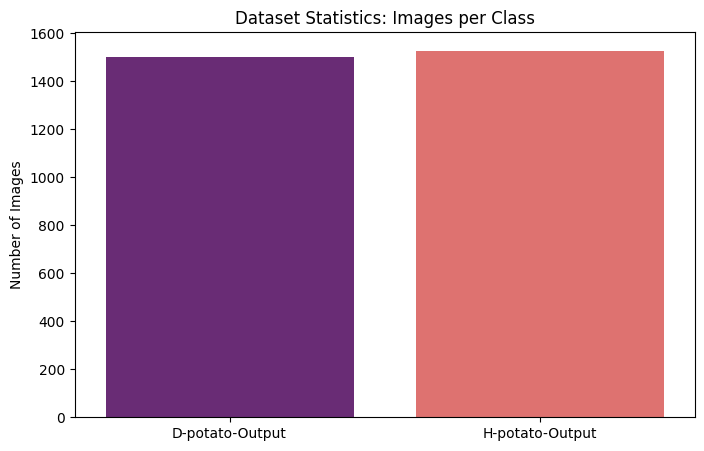

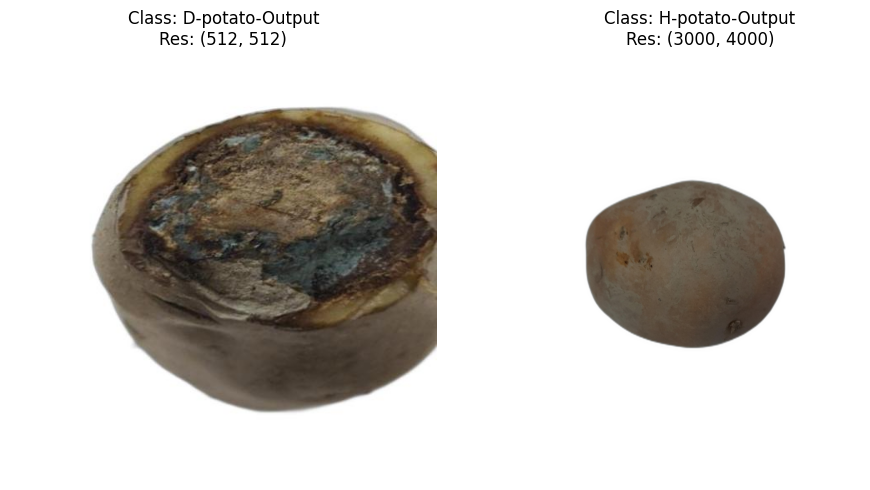

In [ ]:
# Define the path where the class folders (D-potato, H-potato) actually live
base_data_path = os.path.join(data_dir, 'Potato Image')

# Get the class names (D-potato-Output, H-potato-Output)
classes = [d for d in os.listdir(base_data_path) if os.path.isdir(os.path.join(base_data_path, d))]

# --- Statistics: Image Counts ---
stats = {cls: len(os.listdir(os.path.join(base_data_path, cls))) for cls in classes}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(stats.keys()), y=list(stats.values()), palette="magma")
plt.title("Dataset Statistics: Images per Class")
plt.ylabel("Number of Images")
plt.show()

# --- Visualization: Sample Images ---
plt.figure(figsize=(10, 5))
for i, cls in enumerate(classes):
    # Get the first image file in the directory
    img_list = os.listdir(os.path.join(base_data_path, cls))
    img_path = os.path.join(base_data_path, cls, img_list[0])
    img = Image.open(img_path)

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls}\nRes: {img.size}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Preprocessing for Deep Learning**
This block prepares the data for a training pipeline by resizing the images and creating a validation split.

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 32

# Create the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_data_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Normalization (Scaling pixels from 0-255 to 0-1)
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

print("Preprocessing complete: Data normalized and ready for model input.")

Found 3027 files belonging to 2 classes.
Using 2422 files for training.
Preprocessing complete: Data normalized and ready for model input.


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras import layers, models, applications

IMG_SIZE = 224 # Standard for most pre-trained models
BATCH_SIZE = 32

# Data Augmentation & Loading
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

# Update 'base_data_path' to your local directory
train_generator = train_datagen.flow_from_directory(
    base_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    base_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2422 images belonging to 2 classes.
Found 605 images belonging to 2 classes.


In [ ]:
def build_model(base_arch, num_classes):
    base_model = base_arch(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    # FIX: Corrected the loss identifier string
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

num_classes = len(train_generator.class_indices)
models_dict = {
    "ResNet50": build_model(applications.ResNet50, num_classes),
    "MobileNetV2": build_model(applications.MobileNetV2, num_classes)
}

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
history_logs = {}
performance_metrics = {}

for name, model in models_dict.items():
    print(f"\n--- Training {name} ---")
    start_train = time.time()
    history = model.fit(train_generator, validation_data=val_generator, epochs=5)
    performance_metrics[name] = {"train_time": time.time() - start_train}
    history_logs[name] = history

# Re-initialize a clean validation generator for testing (No Shuffle)
test_generator = train_datagen.flow_from_directory(
    base_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # CRITICAL for Confusion Matrix
)


--- Training ResNet50 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.5370 - loss: 0.8324 - val_accuracy: 0.7884 - val_loss: 0.6009
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.6791 - loss: 0.6100 - val_accuracy: 0.7223 - val_loss: 0.5717
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.7380 - loss: 0.5586 - val_accuracy: 0.7917 - val_loss: 0.4972
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7502 - loss: 0.5270 - val_accuracy: 0.6744 - val_loss: 0.5508
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.7638 - loss: 0.5104 - val_accuracy: 0.7504 - val_loss: 0.5198

--- Training MobileNetV2 ---
Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.8330 - loss: 0.3994 - val_accuracy: 0.9719 - val_loss: 0.0782
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9781 - loss: 0.0550 - val_accuracy: 0.9802 - val_loss: 0.0632
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.9833 - loss: 0.0403 - va

19/19 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step

ResNet50 RESULTS
Test Time (Total): 46.29s
                 precision    recall  f1-score   support

D-potato-Output       0.69      0.93      0.79       300
H-potato-Output       0.89      0.59      0.71       305

       accuracy                           0.76       605
      macro avg       0.79      0.76      0.75       605
   weighted avg       0.79      0.76      0.75       605



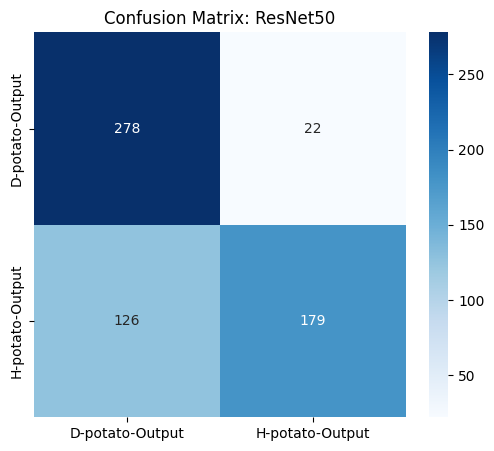

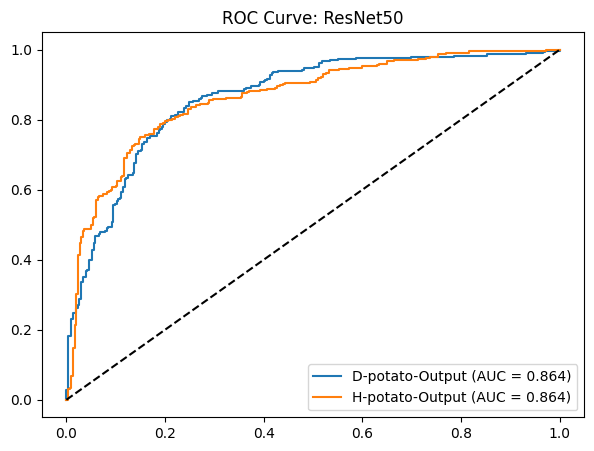

19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step

MobileNetV2 RESULTS
Test Time (Total): 41.85s
                 precision    recall  f1-score   support

D-potato-Output       0.98      1.00      0.99       300
H-potato-Output       1.00      0.98      0.99       305

       accuracy                           0.99       605
      macro avg       0.99      0.99      0.99       605
   weighted avg       0.99      0.99      0.99       605



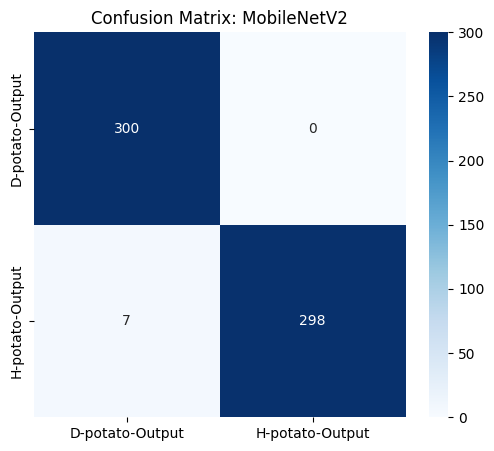

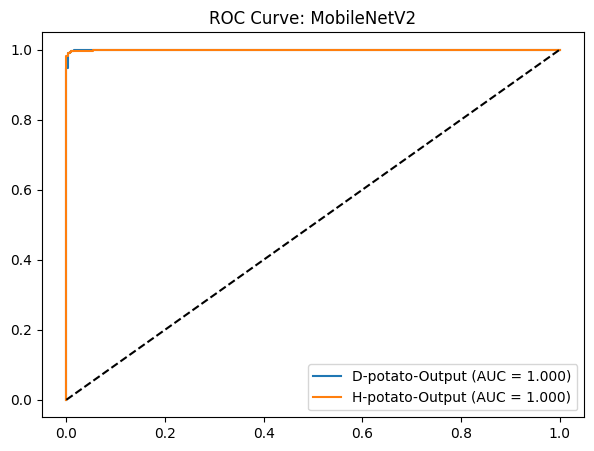

In [ ]:
def evaluate_model(name, model, generator):
    start_test = time.time()
    y_pred_probs = model.predict(generator)
    test_time = time.time() - start_test

    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes
    class_labels = list(generator.class_indices.keys())

    # Metrics
    print(f"\n{'='*20}\n{name} RESULTS\n{'='*20}")
    print(f"Test Time (Total): {test_time:.2f}s")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
                cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    # ROC Curve
    plt.figure(figsize=(7, 5))
    for i, label in enumerate(class_labels):
        # Handle binary vs multiclass ROC
        fpr, tpr, _ = roc_curve(y_true == i, y_pred_probs[:, i])
        plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.3f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve: {name}")
    plt.legend()
    plt.show()

for name, model in models_dict.items():
    evaluate_model(name, model, test_generator)

Does the application of geometric data augmentation (rotation, flipping, zooming) significantly improve the model's ability to generalize to new, unseen field images compared to training on raw images alone?

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

# 1. RAW DATA PIPELINE (No Augmentation)
raw_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# 2. AUGMENTED DATA PIPELINE (Geometric Transformations)
aug_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,      # Simulated wind/camera tilt
    width_shift_range=0.2,  # Off-center framing
    height_shift_range=0.2,
    zoom_range=0.2,         # Different distances from leaf
    horizontal_flip=True,   # Leaf orientation
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Loaders
train_raw = raw_datagen.flow_from_directory(base_data_path, target_size=(IMG_SIZE, IMG_SIZE),
                                            batch_size=BATCH_SIZE, subset='training')
train_aug = aug_datagen.flow_from_directory(base_data_path, target_size=(IMG_SIZE, IMG_SIZE),
                                            batch_size=BATCH_SIZE, subset='training')
val_gen = raw_datagen.flow_from_directory(base_data_path, target_size=(IMG_SIZE, IMG_SIZE),
                                           batch_size=BATCH_SIZE, subset='validation', shuffle=False)

Found 2422 images belonging to 2 classes.
Found 2422 images belonging to 2 classes.
Found 605 images belonging to 2 classes.


In [ ]:
def build_experiment_model():
    base = tf.keras.applications.MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = False
    return models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(num_classes, activation='softmax')
    ])

# Model A: Trained on Raw Data
model_raw = build_experiment_model()
model_raw.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Training Raw Model...")
history_raw = model_raw.fit(train_raw, validation_data=val_gen, epochs=5)

# Model B: Trained on Augmented Data
model_aug = build_experiment_model()
model_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\nTraining Augmented Model...")
history_aug = model_aug.fit(train_aug, validation_data=val_gen, epochs=5)

Training Raw Model...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.7600 - loss: 0.4550 - val_accuracy: 0.9471 - val_loss: 0.1286
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.9698 - loss: 0.0884 - val_accuracy: 0.9719 - val_loss: 0.0809
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.9835 - loss: 0.0575 - val_accuracy: 0.9802 - val_loss: 0.0671
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.9939 - loss: 0.0414 - val_accuracy: 0.9868 - val_loss: 0.0472
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9957 - loss: 0.0292 - val_accuracy: 0.9868 - val_loss: 0.0385

Training Augmented Model...
Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.7691 - loss: 0.4616 - val_accuracy: 0.9240 - val_loss: 0.1714
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.9509 - loss: 0.1355 - val_accuracy: 0.9570 - val_loss: 0.1251
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.9752 - loss: 0.0795 - val_acc

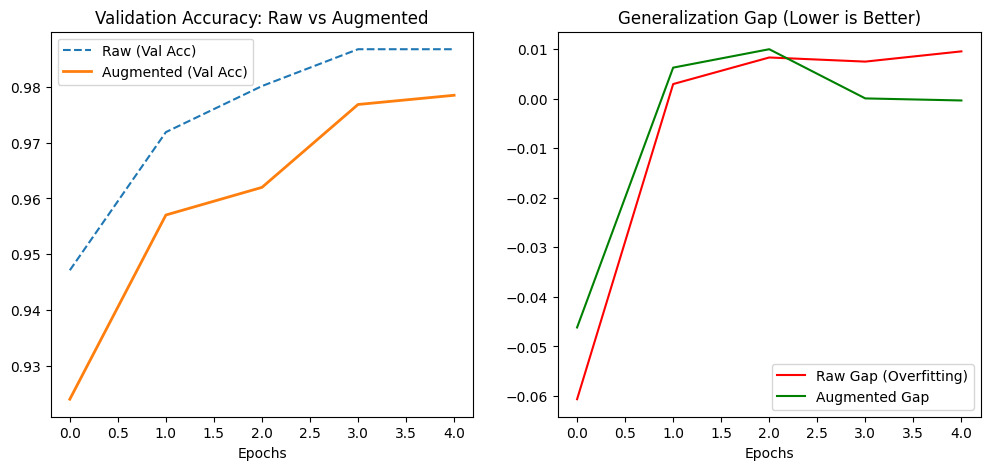

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(history_raw.history['val_accuracy'], label='Raw (Val Acc)', linestyle='--')
plt.plot(history_aug.history['val_accuracy'], label='Augmented (Val Acc)', linewidth=2)
plt.title('Validation Accuracy: Raw vs Augmented')
plt.xlabel('Epochs')
plt.legend()

# Plot Generalization Gap (Train Acc - Val Acc)
plt.subplot(1, 2, 2)
gap_raw = np.array(history_raw.history['accuracy']) - np.array(history_raw.history['val_accuracy'])
gap_aug = np.array(history_aug.history['accuracy']) - np.array(history_aug.history['val_accuracy'])
plt.plot(gap_raw, label='Raw Gap (Overfitting)', color='red')
plt.plot(gap_aug, label='Augmented Gap', color='green')
plt.title('Generalization Gap (Lower is Better)')
plt.xlabel('Epochs')
plt.legend()

plt.show()